In [1]:
import velocycle as vc
from velocycle import *

In [2]:
# generic & ml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pyro
import copy
import scipy
import pycircstat
import pickle
from scipy.stats import pearsonr
from scipy.linalg import lstsq
import statsmodels.api as sm

# scRNA-seq
import scanpy as sc
import anndata

In [3]:
USE_GPU = False
if USE_GPU and torch.cuda.is_available():
    print("Will use GPU")
    device = torch.device("cuda:0")
else:
    print("Will use CPU")
    device = torch.device("cpu")

Will use CPU


In [35]:
ct="ILso"
data = sc.read_h5ad("../intermediates/2502/250409_anndata/"+ct+".h5ad")
data.obs["batch"] = "pharyngeal_muscle"

In [36]:
sc.pp.filter_genes(data, min_cells=int((data.n_obs)*0.01))

In [37]:
data = data[:, (data.layers["unspliced"].toarray().mean(0) > 0.02)].copy()
data = data[:, data.layers["spliced"].toarray().mean(0) > 0.02].copy()

In [38]:
data.layers["spliced"].shape

(1920, 509)

In [39]:
batch_design_matrix = preprocessing.make_design_matrix(data, ids="batch")

In [40]:
preprocessing.normalize_total(data)

/gpfs/gibbs/project/hammarlund/aw853/conda_envs/velocycle_jupyter/lib/python3.8/site-packages/velocycle/preprocessing.py:100: RuntimeWarning: divide by zero encountered in divide
  norm_factors = np.mean(anndata.obs["n_ucounts"]) / np.array(anndata.obs["n_ucounts"])
/gpfs/gibbs/project/hammarlund/aw853/conda_envs/velocycle_jupyter/lib/python3.8/site-packages/velocycle/preprocessing.py:101: RuntimeWarning: invalid value encountered in multiply
  anndata.layers["U_sz"] = (norm_factors * anndata.layers["unspliced"].toarray().T).T


In [41]:
full_keep_genes = data.var_names

In [42]:
cycle_prior = cycle.Cycle.trivial_prior(gene_names=full_keep_genes, harmonics=1)

In [43]:
cycle_prior

In [44]:
# Keep only genes from biologically-relevant gene set that are present in the current dataset
cycle_prior, data_to_fit = preprocessing.filter_shared_genes(cycle_prior, data, filter_type="intersection")

In [45]:
# Update the priors for gene harmonics
# to gene-specific means and stds
S = data_to_fit.layers['spliced'].toarray()
S_means = S.mean(axis=0) #sum over cells
nu0 = np.log(S_means)

# Mean prior
S_frac_means=np.vstack((nu0, 0*nu0, 0*nu0))
cycle_prior.set_means(S_frac_means)

# Standard deviation prior
nu0std = np.std(np.log(S+1), axis=0)/2
S_frac_stds=np.vstack((nu0std, 0.5*nu0std, 0.5*nu0std))
cycle_prior.set_stds(S_frac_stds)



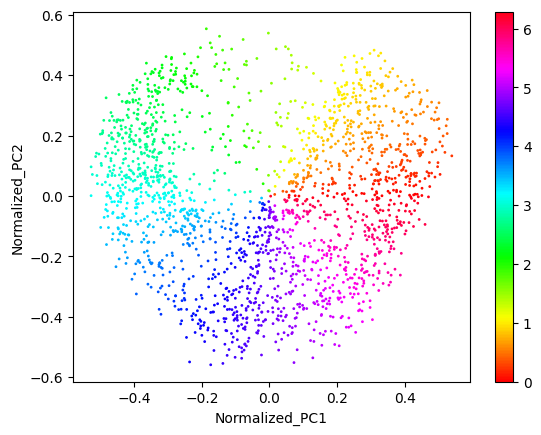

In [46]:
# Obtain a PCA prior for individual cell phases
# The prior for cell cycle coordinates are taken from the first two components of the PCA
# This is the only step of the model that relies on log transformed counts - but still no smoothing is performed
data_to_fit.layers["S_sz_log"] = np.log(data_to_fit.layers["S_sz"]+1)
phase_prior = phases.Phases.from_pca_heuristic(data_to_fit, 
                                               genes_to_use=full_keep_genes, 
                                               layer='S_sz_log',
                                               concentration=5.0, plot=True, small_count=1)

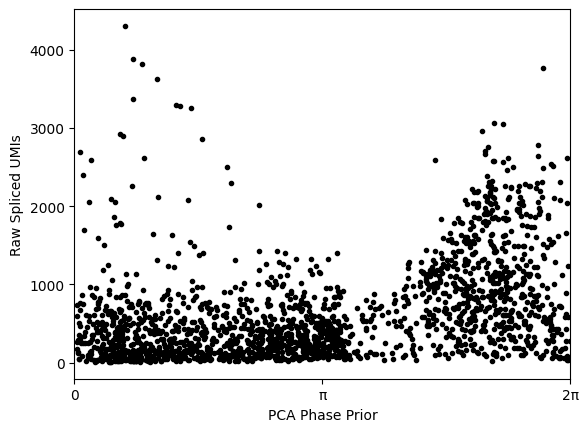

In [47]:
# Shift the phase prior to have maximum correlation with the total raw UMI counts
(shift, maxcor, allcor) = phase_prior.max_corr(data_to_fit.obs.n_scounts)
phase_prior.rotate(angle=-shift)
plt.plot(phase_prior.phis, data_to_fit.obs.n_scounts, '.', c='black')
plt.xlim(0, np.pi*2)
plt.xticks([0, np.pi, 2*np.pi],["0", "π", "2π"])
plt.xlabel("PCA Phase Prior")
plt.ylabel("Raw Spliced UMIs")
plt.show()

In [48]:
pyro.clear_param_store()

In [49]:
# Call a preprocessing function to metaparameters to provide to Pyro
metapar = preprocessing.preprocess_for_phase_estimation(anndata=data_to_fit, 
                                          cycle_obj=cycle_prior, 
                                          phase_obj=phase_prior, 
                                          design_mtx=batch_design_matrix,
                                          n_harmonics=1,
                                          device = device,
                                          with_delta_nu=False)

In [50]:
# Define a pyro object for phase inference
phase_fit = phase_inference_model.PhaseFitModel(metaparams=metapar)

In [51]:


# Optional commands to check the plate dimensions for the model
# phase_fit.check_model()
# phase_fit.check_guide()



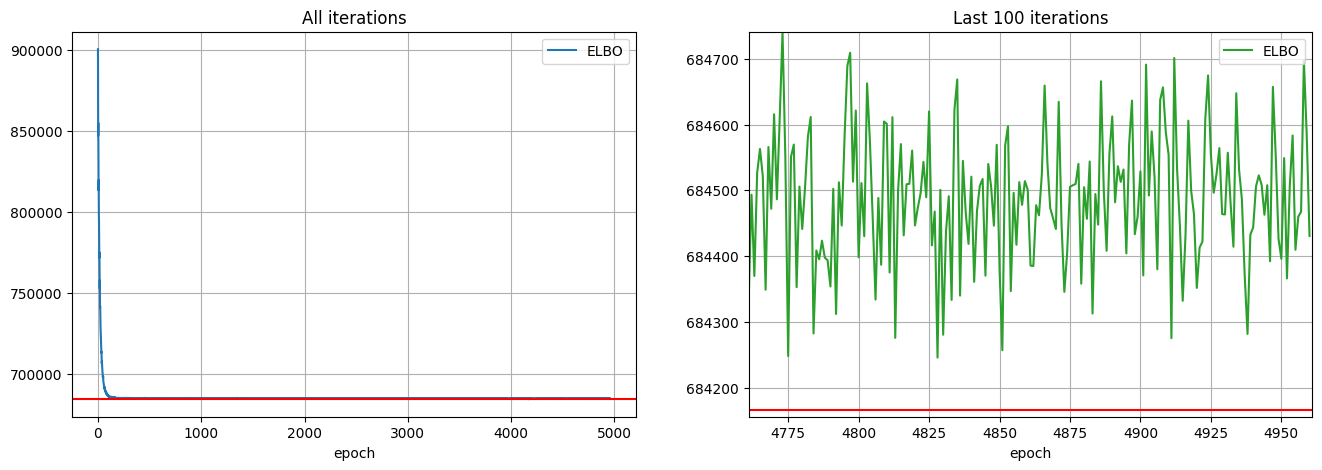

In [52]:
# Perform training using a decaying learning rate
num_steps = 5000
initial_lr = 0.03
final_lr = 0.005
gamma = final_lr / initial_lr
lrd = gamma ** (1 / num_steps)
adam = pyro.optim.ClippedAdam({'lr': initial_lr, 'lrd': lrd, 'betas': (0.80, 0.99)})

phase_fit.fit(optimizer=adam, num_steps=num_steps)

In [53]:
# Put estimations in new objects
cycle_pyro = phase_fit.cycle_pyro
phase_pyro = phase_fit.phase_pyro


fit_ElogS = phase_fit.posterior["ElogS"].squeeze().numpy() # raw counts
fit_ElogS2 = phase_fit.posterior["ElogS2"].squeeze().numpy() # size-normalized counts for cleaner visualization

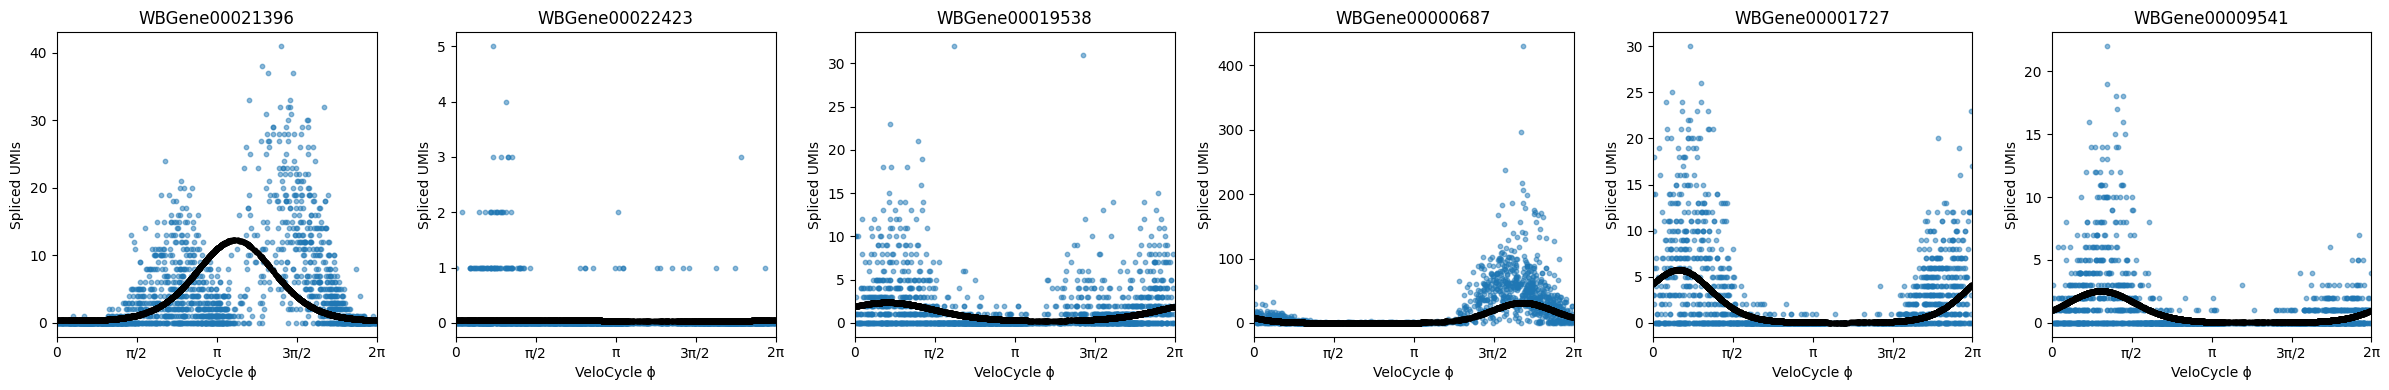

In [57]:
# Visualize the results for a subset of genes, colored by categorical cell cycle phase
name2color = {'G1':"tab:blue", 'S':"tab:orange", 'G2M':"tab:green"}
gene_list = ['WBGene00021396','WBGene00022423','WBGene00019538','WBGene00000687','WBGene00001727','WBGene00009541']
gene_names = np.array(data_to_fit.var.index)
plt.figure(None,(24, 4))
ix = 1
for i in range(0, len(gene_list)):
    g = gene_list[i]
    plt.subplot(1, len(gene_list), ix)
    plt.scatter(phase_pyro.phis, 
                metapar.S[np.where(gene_names==g)[0][0], :].squeeze().cpu().numpy(), 
                s=10, alpha=0.5)
    plt.scatter(phase_pyro.phis, 
                np.exp(fit_ElogS2[np.where(gene_names==g)[0][0], :]), 
                s=10, c="black")
    plt.title(g)
    plt.xlabel("VeloCycle ϕ")
    plt.ylabel("Spliced UMIs")
    plt.xlim(0, 2*np.pi)
    plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],["0", "π/2", "π", "3π/2", "2π"])
    ix+=1
plt.tight_layout()
plt.show()

In [56]:
# select genes to plot that are present in the data

gene_names = np.array(data_to_fit.var.index)
gene_list = ['WBGene00021396','WBGene00001735','WBGene00019663','WBGene00018256','WBGene00000677','WBGene00018928','WBGene00021927','WBGene00016797','WBGene00044463','WBGene00022423','WBGene00019538','WBGene00019540','WBGene00000683','WBGene00021876','WBGene00003153','WBGene00021375','WBGene00022608','WBGene00021372','WBGene00018145','WBGene00017936','WBGene00000610','WBGene00019955','WBGene00017901','WBGene00017900','WBGene00017923','WBGene00000685','WBGene00006745','WBGene00016955','WBGene00015680','WBGene00002245','WBGene00022245','WBGene00001858','WBGene00022727','WBGene00015551','WBGene00000687','WBGene00015531','WBGene00001713','WBGene00015620','WBGene00016700','WBGene00000603','WBGene00004732','WBGene00006620','WBGene00005019','WBGene00007221','WBGene00008110','WBGene00012433','WBGene00010317','WBGene00009541','WBGene00006949','WBGene00007886','WBGene00000953','WBGene00001396','WBGene00009323','WBGene00009133','WBGene00008150','WBGene00008512','WBGene00008511','WBGene00004140','WBGene00011238','WBGene00001163','WBGene00011183','WBGene00003568','WBGene00003876','WBGene00012794','WBGene00004892','WBGene00002827','WBGene00014090','WBGene00010670','WBGene00009435','WBGene00009218','WBGene00009957','WBGene00001393','WBGene00004156','WBGene00012635','WBGene00009926','WBGene00010391','WBGene00013457','WBGene00013331','WBGene00013312','WBGene00007823','WBGene00008707','WBGene00019184','WBGene00019185','WBGene00021041','WBGene00021754','WBGene00016029','WBGene00020551','WBGene00019329','WBGene00004894','WBGene00021446','WBGene00019198','WBGene00021919','WBGene00009374','WBGene00002267','WBGene00006591','WBGene00011279','WBGene00011282','WBGene00009647','WBGene00011205','WBGene00001631','WBGene00011112','WBGene00010907','WBGene00008655','WBGene00003588','WBGene00018675','WBGene00020970','WBGene00017166','WBGene00016197','WBGene00016195','WBGene00017775','WBGene00001166','WBGene00015480','WBGene00020437','WBGene00015483','WBGene00003523','WBGene00019908','WBGene00020646','WBGene00015163','WBGene00022816','WBGene00022793','WBGene00045246','WBGene00015752','WBGene00019882','WBGene00044443','WBGene00015519','WBGene00015523','WBGene00018418','WBGene00014030','WBGene00001242','WBGene00010573','WBGene00008000','WBGene00001570','WBGene00014016','WBGene00011221','WBGene00008019','WBGene00012648','WBGene00012363','WBGene00012973','WBGene00012941','WBGene00012943','WBGene00013438','WBGene00013732','WBGene00012545','WBGene00014178','WBGene00000672','WBGene00012796','WBGene00004075','WBGene00013578','WBGene00010661','WBGene00022861','WBGene00003407','WBGene00020215','WBGene00003104','WBGene00018656','WBGene00018591','WBGene00003968','WBGene00001484','WBGene00019866','WBGene00018743','WBGene00021529','WBGene00015791','WBGene00002220','WBGene00004124','WBGene00006810','WBGene00000990','WBGene00004729','WBGene00006952','WBGene00018533','WBGene00018532','WBGene00001441','WBGene00002987','WBGene00015822','WBGene00044724','WBGene00219362','WBGene00206361','WBGene00018376','WBGene00019960','WBGene00019403','WBGene00019760','WBGene00022500','WBGene00022614','WBGene00006861','WBGene00000039','WBGene00021320','WBGene00021324','WBGene00016133','WBGene00003990','WBGene00020736','WBGene00020738','WBGene00018515','WBGene00001984','WBGene00018641','WBGene00004219','WBGene00015803','WBGene00017687','WBGene00017445','WBGene00015169','WBGene00015168','WBGene00016468','WBGene00018519','WBGene00019351','WBGene00000523','WBGene00000526','WBGene00004949','WBGene00000747','WBGene00017244','WBGene00000083','WBGene00270320','WBGene00022665','WBGene00018467','WBGene00006890','WBGene00019780','WBGene00019781','WBGene00017420','WBGene00002127','WBGene00018282','WBGene00006942','WBGene00004998','WBGene00020137','WBGene00017570','WBGene00003752','WBGene00009888','WBGene00007516','WBGene00001123','WBGene00011077','WBGene00011078','WBGene00007652','WBGene00003368','WBGene00000908','WBGene00012261','WBGene00012255','WBGene00012256','WBGene00012257','WBGene00013975','WBGene00000040','WBGene00009930','WBGene00006066','WBGene00011443','WBGene00011441','WBGene00011440','WBGene00004859','WBGene00007116','WBGene00010221','WBGene00009635','WBGene00010423','WBGene00000482','WBGene00007343','WBGene00003623','WBGene00008600','WBGene00007285','WBGene00004126','WBGene00007848','WBGene00023500','WBGene00004301','WBGene00002282','WBGene00004950','WBGene00050939','WBGene00044138','WBGene00000902','WBGene00008978','WBGene00008605','WBGene00010356','WBGene00007262','WBGene00003681','WBGene00007877','WBGene00009561','WBGene00003532','WBGene00001148','WBGene00007174','WBGene00018187','WBGene00015545','WBGene00020143','WBGene00019347','WBGene00018031','WBGene00303423','WBGene00000792','WBGene00007068','WBGene00016902','WBGene00020283','WBGene00003548','WBGene00001707','WBGene00022160','WBGene00235158','WBGene00021468','WBGene00020985','WBGene00002174','WBGene00004077','WBGene00000625','WBGene00002135','WBGene00002134','WBGene00004217','WBGene00001430','WBGene00003072','WBGene00003516','WBGene00021629','WBGene00022831','WBGene00015704','WBGene00019771','WBGene00004900','WBGene00004771','WBGene00001491','WBGene00019693','WBGene00004224','WBGene00000493','WBGene00020693','WBGene00016422','WBGene00015027','WBGene00016749','WBGene00022591','WBGene00003798','WBGene00020413','WBGene00016264','WBGene00010370','WBGene00012165','WBGene00000637','WBGene00003622','WBGene00012140','WBGene00007042','WBGene00011971','WBGene00001647','WBGene00010291','WBGene00010110','WBGene00010566','WBGene00013960','WBGene00008652','WBGene00000777','WBGene00010621','WBGene00011629','WBGene00009342','WBGene00003036','WBGene00005023','WBGene00008666','WBGene00007054','WBGene00009119','WBGene00000912','WBGene00013127','WBGene00012317','WBGene00009318','WBGene00002232','WBGene00012948','WBGene00013135','WBGene00004231','WBGene00012274','WBGene00009825','WBGene00013404','WBGene00013673','WBGene00013683','WBGene00014150','WBGene00018976','WBGene00021309','WBGene00020396','WBGene00020343','WBGene00017719','WBGene00001758','WBGene00020952','WBGene00001722','WBGene00269437','WBGene00021624','WBGene00021975','WBGene00001727','WBGene00020256','WBGene00044542','WBGene00019603','WBGene00002637','WBGene00000979','WBGene00000802','WBGene00017535','WBGene00017430','WBGene00001073','WBGene00175027','WBGene00021963','WBGene00001428','WBGene00001719','WBGene00015857','WBGene00020554','WBGene00019113','WBGene00016101','WBGene00002017','WBGene00004216','WBGene00017097','WBGene00018090','WBGene00077697','WBGene00011572','WBGene00011575','WBGene00010697','WBGene00000723','WBGene00004083','WBGene00009331','WBGene00007553','WBGene00077693','WBGene00011430','WBGene00000065','WBGene00012152','WBGene00010744','WBGene00000727','WBGene00000728','WBGene00010191','WBGene00000982','WBGene00009532','WBGene00009386','WBGene00009791','WBGene00044631','WBGene00004855','WBGene00010205','WBGene00006539','WBGene00008303','WBGene00008304','WBGene00000228','WBGene00007552','WBGene00044198','WBGene00001429','WBGene00013896','WBGene00013897','WBGene00013899','WBGene00011590','WBGene00011796','WBGene00003031','WBGene00138724','WBGene00001137','WBGene00007931','WBGene00009980','WBGene00009986','WBGene00011326','WBGene00009973','WBGene00009081','WBGene00011136','WBGene00008832','WBGene00008993','WBGene00009978','WBGene00003674','WBGene00012019','WBGene00012304','WBGene00013082','WBGene00013481','WBGene00012689','WBGene00012670','WBGene00012628','WBGene00012186','WBGene00077786','WBGene00017747','WBGene00017748','WBGene00015188','WBGene00019280','WBGene00000645','WBGene00019285','WBGene00000778','WBGene00015404','WBGene00015645','WBGene00021095','WBGene00018572','WBGene00235164','WBGene00004751','WBGene00021052','WBGene00015301','WBGene00002252','WBGene00022743','WBGene00015135','WBGene00018050','WBGene00022283','WBGene00001755','WBGene00022759','WBGene00006997','WBGene00003949','WBGene00017220','WBGene00015942','WBGene00022649','WBGene00020023','WBGene00004015','WBGene00019372','WBGene00019426','WBGene00020894','WBGene00020501','WBGene00020478','WBGene00017968','WBGene00016276','WBGene00003526','WBGene00023416','WBGene00006956','WBGene00015517','WBGene00004264','WBGene00008800','WBGene00008803','WBGene00010881','WBGene00000220','WBGene00011884','WBGene00011888','WBGene00011977','WBGene00011978','WBGene00000170','WBGene00010943','WBGene00009450','WBGene00014131','WBGene00000995','WBGene00014164','WBGene00004017','WBGene00007420','WBGene00011661','WBGene00004134','WBGene00010321','WBGene00003107','WBGene00000616','WBGene00004222','WBGene00001753','WBGene00004215','WBGene00009355','WBGene00011522','WBGene00011530','WBGene00006444','WBGene00009692','WBGene00013266','WBGene00009400','WBGene00010267','WBGene00004232','WBGene00008932','WBGene00004120','WBGene00003388','WBGene00003246','WBGene00008579','WBGene00008496','WBGene00007545','WBGene00013852','WBGene00013171','WBGene00004234']
in_gene_names = np.isin(gene_list, gene_names)
genes_in_names = np.array(gene_list)[in_gene_names]
genes_in_names

array(['WBGene00021396', 'WBGene00016797', 'WBGene00022423',
       'WBGene00019538', 'WBGene00000683', 'WBGene00000610',
       'WBGene00016955', 'WBGene00001858', 'WBGene00000687',
       'WBGene00015531', 'WBGene00015620', 'WBGene00016700',
       'WBGene00000603', 'WBGene00004732', 'WBGene00009541',
       'WBGene00008150', 'WBGene00011238', 'WBGene00004156',
       'WBGene00013331', 'WBGene00016029', 'WBGene00019198',
       'WBGene00006591', 'WBGene00009647', 'WBGene00001631',
       'WBGene00008655', 'WBGene00016197', 'WBGene00016195',
       'WBGene00017775', 'WBGene00015480', 'WBGene00020437',
       'WBGene00003523', 'WBGene00019908', 'WBGene00045246',
       'WBGene00044443', 'WBGene00010573', 'WBGene00011221',
       'WBGene00012363', 'WBGene00012545', 'WBGene00014178',
       'WBGene00012796', 'WBGene00018656', 'WBGene00003968',
       'WBGene00001484', 'WBGene00006952', 'WBGene00018532',
       'WBGene00015822', 'WBGene00018376', 'WBGene00019960',
       'WBGene00019403',

In [58]:


# Examine the periodicity and geometry of fitted genes
xs = phase_fit.fourier_coef[1]
ys = phase_fit.fourier_coef[2]
r = np.log10( np.sqrt(xs**2+ys**2) / phase_fit.fourier_coef_sd[1:, :].sum(0) )
angle = np.arctan2(xs, ys)
angle = (angle)%(2*np.pi)

phis_df = pd.DataFrame([angle, r])
phis_df.columns = data_to_fit.var.index

cycle_data_frame = pd.concat([phase_fit.cycle_pyro.means, phase_fit.cycle_pyro.stds, phis_df]).T
cycle_data_frame.columns = ["nu0 mean", "nu1sin mean", "nu1cos mean", "nu0 std", "nu1sin std", "nu1cos std", "peak_phase", "amplitude"]
cycle_data_frame.head()



,nu0 mean,nu1sin mean,nu1cos mean,nu0 std,nu1sin std,nu1cos std,peak_phase,amplitude
WBGene00000018,-1.429912,-0.277030,-0.099612,0.051482,0.055221,0.064184,4.367213,0.391908
WBGene00000068,-2.284644,0.145340,0.036933,0.070721,0.048538,0.050354,1.321950,0.180813
WBGene00000100,-1.808229,0.128229,-0.138186,0.065258,0.054641,0.055189,2.393553,0.234626
WBGene00000140,-0.917218,0.201422,-0.436121,0.052124,0.061705,0.061614,2.708929,0.590561
WBGene00000168,-3.086261,0.098209,-0.066192,0.059834,0.034070,0.036331,2.163851,0.225894


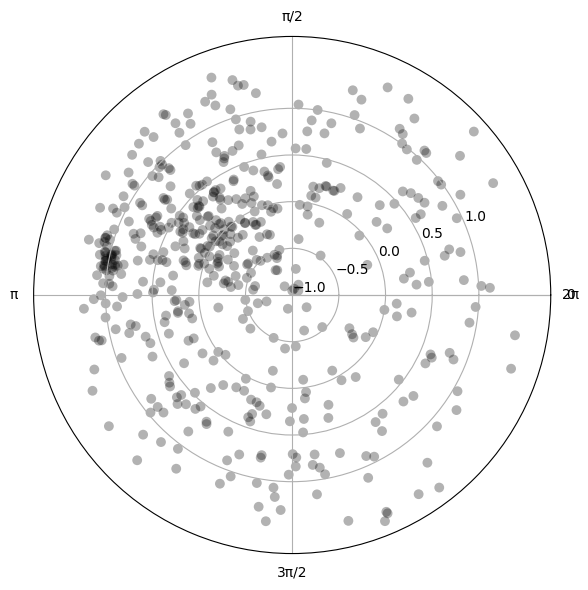

In [59]:
# View gene periodicity estimates with a polar plot
phase_fit.polar_plot()

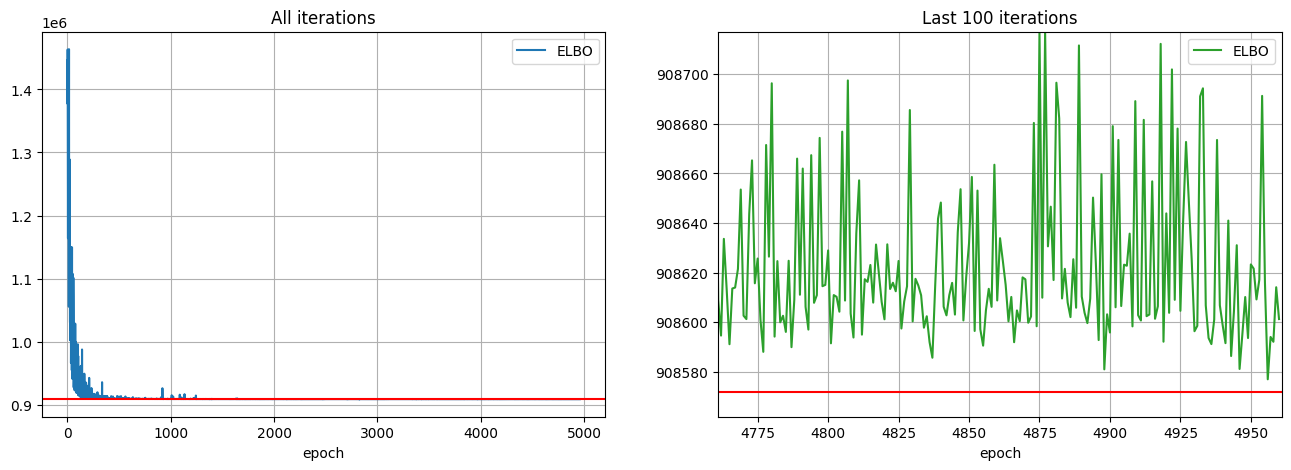

In [60]:
pyro.clear_param_store()

condition_design_matrix = copy.deepcopy(batch_design_matrix) # they are the same since there is only one sample

speed_prior = angularspeed.AngularSpeed.trivial_prior(condition_names=["pharyngeal_muscle"], harmonics=0)

# Condition the model on variables learned during manifold-learning
condition_on_dict = {"ϕxy":phase_pyro.phi_xy_tensor.T.to(device),
                     "ν": cycle_pyro.means_tensor.T.unsqueeze(-2).to(device),
                     "shape_inv": torch.tensor(phase_fit.disp_pyro).unsqueeze(-1).to(device)}

metaparameters_velocity = preprocessing.preprocess_for_velocity_estimation(data_to_fit, 
                                                             cycle_pyro, 
                                                             phase_pyro, 
                                                             speed_prior,
                                                             condition_design_matrix,
                                                             batch_design_matrix,
                                                             n_harmonics=1,
                                                             count_factor=metapar.count_factor,
                                                             ω_n_harmonics=0, 
                                                             device=device, 
                                                             condition_on=condition_on_dict,
                                                             with_delta_nu=False)

velocity_fit0 = velocity_inference_model.VelocityFitModel(metaparams=metaparameters_velocity, 
                                                         condition_on=condition_on_dict)

# velocity_fit0.check_model()
# velocity_fit0.check_guide()

num_steps = 5000
initial_lr = 0.03
final_lr = 0.005
gamma = final_lr / initial_lr
lrd = gamma ** (1 / num_steps)
adam = pyro.optim.ClippedAdam({'lr': initial_lr, 'lrd': lrd, 'betas': (0.80, 0.99)})

velocity_fit0.fit(optimizer=adam, num_steps=num_steps)




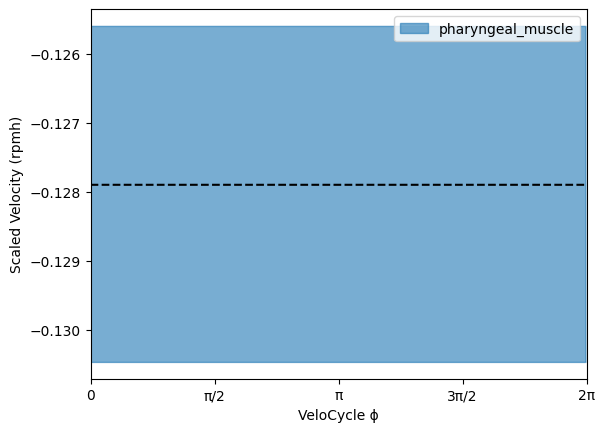

In [61]:

# Put estimations in new objects
cycle_pyro = velocity_fit0.cycle_pyro
phase_pyro = velocity_fit0.phase_pyro
speed_pyro = velocity_fit0.speed_pyro

fit_ElogS = velocity_fit0.posterior["ElogS"].squeeze()
fit_ElogU = velocity_fit0.posterior["ElogU"].squeeze()

fit_ElogS2 = velocity_fit0.posterior["ElogS2"].squeeze()
fit_ElogU2 = velocity_fit0.posterior["ElogU2"].squeeze()

log_gammas = velocity_fit0.log_gammas
log_betas = velocity_fit0.log_betas

speed_pyro.means


# Store entire posterior sampling into an object
full_pps_velo = velocity_fit0.posterior

# Visualize the constant velocity estimate
omega = full_pps_velo["ω"].squeeze().numpy() / torch.exp(torch.mean(full_pps_velo["logγg"].squeeze().mean(0).detach())).numpy()
phi = phase_pyro.phis
omegas = []
phis = []
n2n = {"pharyngeal_muscle":0}
ids = np.array([n2n[i] for i in np.array(data_to_fit.obs["batch"])])
for i in range(len(data_to_fit.obs["batch"].unique())):
    omega1 = omega[:,np.where(ids == i)]
    phi1 = phi[np.where(ids == i)]
    omegas.append(omega1)
    phis.append(phi1)

labels = np.array(data_to_fit.obs["batch"].unique())

colors = ["tab:blue"]
for i in range(len(omegas)):
    plt.plot(phis[i][np.argsort(phis[i])], omegas[i].mean(0)[0][np.argsort(phis[i])], c="black", linestyle='dashed')
    
    tmp5 = np.percentile(omega[:, ids==i], 5, axis=0)
    tmp95 = np.percentile(omega[:, ids==i], 95, axis=0)
    phi_i = phi[ids==i] 
    plt.fill_between(x=phi_i[np.argsort(phi_i)],
                     y1=tmp5[np.argsort(phi_i)], 
                     y2=tmp95[np.argsort(phi_i)], 
                     alpha=0.6, color=colors[i], label = labels[i])

plt.xlabel("VeloCycle ϕ")
plt.ylabel("Scaled Velocity (rpmh)")
plt.xlim(0, 2*np.pi)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],["0", "π/2", "π", "3π/2", "2π"])
plt.legend()
plt.show()

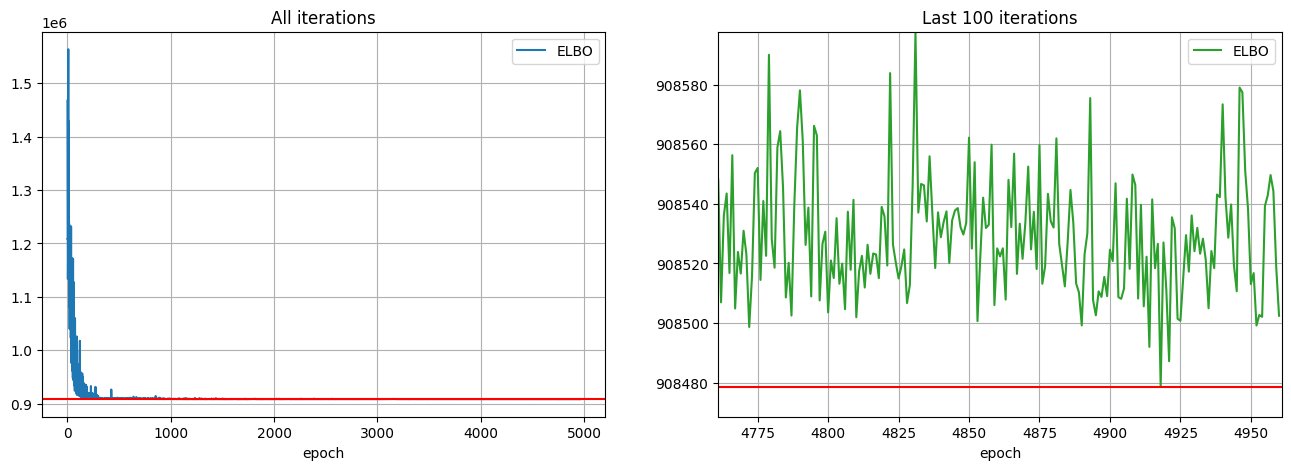

In [62]:
pyro.clear_param_store()

condition_design_matrix = copy.deepcopy(batch_design_matrix)

speed_prior = angularspeed.AngularSpeed.trivial_prior(condition_names=["pharyngeal_muscle"], harmonics=1)

condition_on_dict = {"ϕxy":phase_pyro.phi_xy_tensor.T.to(device),
                     "ν": cycle_pyro.means_tensor.T.unsqueeze(-2).to(device),
                     "shape_inv": torch.tensor(phase_fit.disp_pyro).unsqueeze(-1).to(device)}

metaparameters_velocity = preprocessing.preprocess_for_velocity_estimation(data_to_fit, 
                                                             cycle_pyro, 
                                                             phase_pyro, 
                                                             speed_prior,
                                                             condition_design_matrix, 
                                                             batch_design_matrix, 
                                                             n_harmonics=1,
                                                             count_factor=metapar.count_factor,
                                                             ω_n_harmonics=1, 
                                                             device=device, 
                                                             condition_on=condition_on_dict,
                                                             with_delta_nu=False)

velocity_fit1 = velocity_inference_model.VelocityFitModel(metaparams=metaparameters_velocity, condition_on=condition_on_dict)

# velocity_fit1.check_model()
# velocity_fit1.check_guide()

num_steps = 5000
initial_lr = 0.03
final_lr = 0.005
gamma = final_lr / initial_lr
lrd = gamma ** (1 / num_steps)
adam = pyro.optim.ClippedAdam({'lr': initial_lr, 'lrd': lrd, 'betas': (0.80, 0.99)})

velocity_fit1.fit(optimizer=adam, num_steps=num_steps)

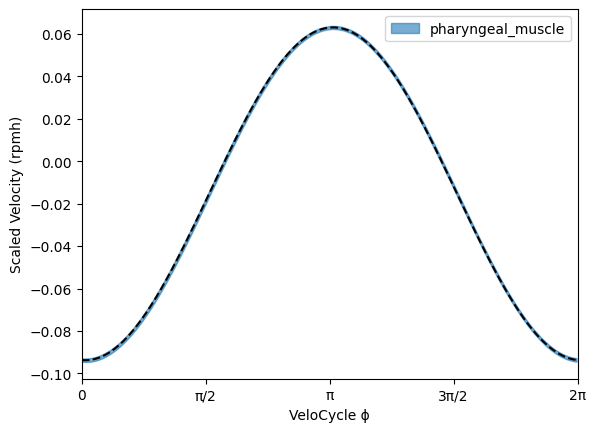

In [63]:
# Put estimations in new objects
cycle_pyro = velocity_fit1.cycle_pyro
phase_pyro = velocity_fit1.phase_pyro
speed_pyro = velocity_fit1.speed_pyro

fit_ElogS = velocity_fit1.posterior["ElogS"].squeeze()
fit_ElogU = velocity_fit1.posterior["ElogU"].squeeze()

fit_ElogS2 = velocity_fit1.posterior["ElogS2"].squeeze()
fit_ElogU2 = velocity_fit1.posterior["ElogU2"].squeeze()

log_gammas = velocity_fit1.log_gammas
log_betas = velocity_fit1.log_betas

speed_pyro.means

# Store entire posterior sampling into an object
full_pps_velo = velocity_fit1.posterior

# Visualize the constant velocity estimate
omega = full_pps_velo["ω"].squeeze().numpy() / torch.exp(torch.mean(full_pps_velo["logγg"].squeeze().mean(0).detach())).numpy()
phi = phase_pyro.phis
omegas = []
phis = []
n2n = {"pharyngeal_muscle":0}
ids = np.array([n2n[i] for i in np.array(data_to_fit.obs["batch"])])
for i in range(len(data_to_fit.obs["batch"].unique())):
    omega1 = omega[:,np.where(ids == i)]
    phi1 = phi[np.where(ids == i)]
    omegas.append(omega1)
    phis.append(phi1)

labels = np.array(data_to_fit.obs["batch"].unique())

colors = ["tab:blue"]
for i in range(len(omegas)):
    plt.plot(phis[i][np.argsort(phis[i])], omegas[i].mean(0)[0][np.argsort(phis[i])], c="black", linestyle='dashed')
    
    tmp5 = np.percentile(omega[:, ids==i], 5, axis=0)
    tmp95 = np.percentile(omega[:, ids==i], 95, axis=0)
    phi_i = phi[ids==i] 
    plt.fill_between(x=phi_i[np.argsort(phi_i)],
                     y1=tmp5[np.argsort(phi_i)], 
                     y2=tmp95[np.argsort(phi_i)], 
                     alpha=0.6, color=colors[i], label = labels[i])

plt.xlabel("VeloCycle ϕ")
plt.ylabel("Scaled Velocity (rpmh)")
plt.xlim(0, 2*np.pi)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],["0", "π/2", "π", "3π/2", "2π"])
plt.legend()
plt.show()



In [64]:
# Measure cell cycle length in true time
# Constant velocity case
from scipy.integrate import trapz
period = []

mean_gamma  = np.exp(np.mean(velocity_fit0.log_gammas))
full_pps_velo = velocity_fit0.posterior
nu_omega = full_pps_velo["νω"].squeeze()/mean_gamma

grid_phi = torch.tensor(np.linspace(0, 2*np.pi, 20)).float()
omegas_on_grid = nu_omega.unsqueeze(-1) @ utils.torch_basis(grid_phi, kind="fourier", num_harmonics=0).T
period = trapz(1/omegas_on_grid, grid_phi)

0.5*(np.percentile(period, 95)-np.percentile(period, 5)), np.mean(period)

(0.933962345123291, -49.132843)

In [65]:
# Non-constant (periodic) velocity case
period = []

mean_gamma  = np.exp(np.mean(velocity_fit1.log_gammas))
full_pps_velo = velocity_fit1.posterior
nu_omega = full_pps_velo["νω"].squeeze()/mean_gamma

grid_phi = torch.tensor(np.linspace(0, 2*np.pi, 20)).float()
omegas_on_grid = nu_omega @ utils.torch_basis(grid_phi, kind="fourier", num_harmonics=1).T
period = trapz(1/omegas_on_grid, grid_phi)

0.5*(np.percentile(period, 95)-np.percentile(period, 5)), np.mean(period)

(12.231147003173827, -54.78799)

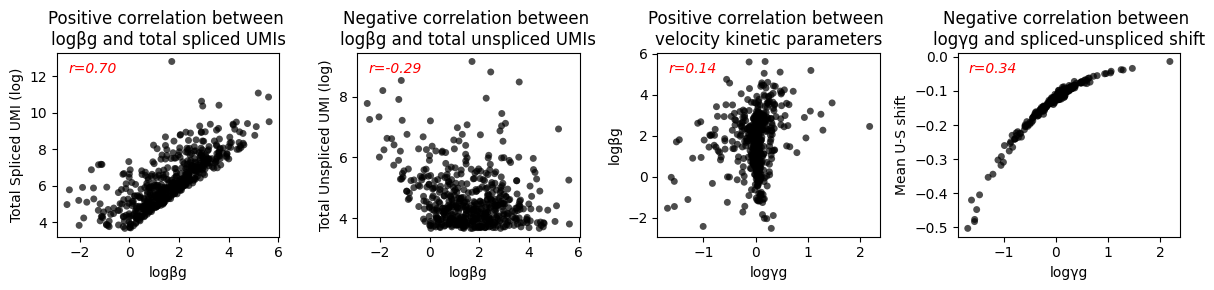

In [66]:
##  Do the velocity kinetic parameters and spliced-unspliced delays correlate with one another?

# Investigate changes to the shift along the cell cycle with non-zero harmonic. Should the shift change?
fit_ElogS2 = velocity_fit0.posterior["ElogS2"]
fit_ElogU2 = velocity_fit0.posterior["ElogU2"]
phis = velocity_fit0.phase_pyro.phis
shift_obs = pycircstat.cdiff(phis[np.argmax(fit_ElogS2.numpy().T, axis=0)], phis[np.argmax(fit_ElogU2.numpy().T, axis=0)])

from scipy.stats import pearsonr

# Helper function to compute the Pearson correlation and add it as text to the plot
def add_pearson_corr_text(x, y, ax):
    corr, _ = pearsonr(x, y)
    ax.text(0.05, 0.95, f"r={corr:.2f}", color='red', ha='left', va='top', transform=ax.transAxes, style='italic')

# Initialize the figure
plt.figure(None, (12, 3))

# Splicing rate vs log spliced counts
ax1 = plt.subplot(1, 4, 1)
ax1.scatter(velocity_fit0.log_betas, np.log(data_to_fit.layers["spliced"].toarray().sum(0)), c='black', edgecolor='none', s=25, alpha=0.7, rasterized=True)
plt.xlabel("logβg")
plt.ylabel("Total Spliced UMI (log)")
plt.title("Positive correlation between \nlogβg and total spliced UMIs")
add_pearson_corr_text(velocity_fit1.log_betas, np.log(data_to_fit.layers["spliced"].toarray().sum(0)), ax1)

# Splicing rate vs log unspliced counts
ax2 = plt.subplot(1, 4, 2)
ax2.scatter(velocity_fit0.log_betas, np.log(data_to_fit.layers["unspliced"].toarray().sum(0)), c='black', edgecolor='none', s=25, alpha=0.7, rasterized=True)
plt.xlabel("logβg")
plt.ylabel("Total Unspliced UMI (log)")
plt.title("Negative correlation between \nlogβg and total unspliced UMIs")
add_pearson_corr_text(velocity_fit1.log_betas, np.log(data_to_fit.layers["unspliced"].toarray().sum(0)), ax2)

# Degradation rate vs splicing rate
ax3 = plt.subplot(1, 4, 3)
ax3.scatter(velocity_fit0.log_gammas, velocity_fit0.log_betas, edgecolor='none', s=25, c='black', alpha=0.7, rasterized=True)
plt.xlabel("logγg")
plt.ylabel("logβg")
plt.title("Positive correlation between \nvelocity kinetic parameters")
add_pearson_corr_text(velocity_fit1.log_gammas, velocity_fit1.log_betas, ax3)

# Degradation rate vs unspliced-spliced delay
ax4 = plt.subplot(1, 4, 4)
ax4.scatter(velocity_fit0.log_gammas, shift_obs, edgecolor='none', s=25, c='black', alpha=0.7, rasterized=True)
plt.xlabel("logγg")
plt.ylabel("Mean U-S shift")
plt.title("Negative correlation between \nlogγg and spliced-unspliced shift")
add_pearson_corr_text(velocity_fit1.log_gammas, shift_obs, ax4)

plt.tight_layout()
plt.show()

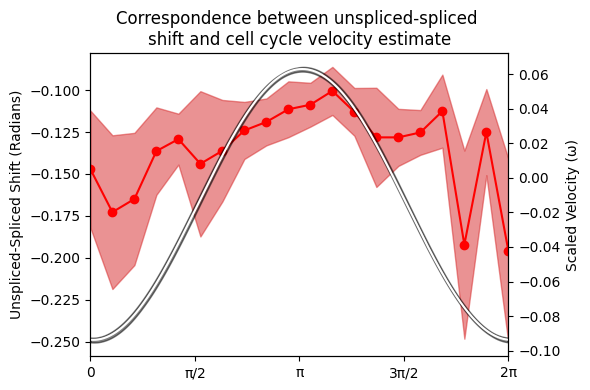

In [67]:
## If we stratify by continuous cell cycle phase bins, do we see unspliced-spliced delays changing along the manifold?

# Stratify by phase of the cell cycle 
# and examine unspliced-spliced delay of genes peaking in those phases
cycle_data_frame["gene"] = cycle_data_frame.index
cycle_data_frame.set_index('gene', inplace=True)

# Define the number of bins
num_bins = 20
bin_width = 2 * np.pi / num_bins

# Calculate the bin index for each gene
cycle_data_frame['bin_index'] = ((cycle_data_frame['peak_phase'] + 2 * np.pi) % (2 * np.pi) / bin_width).astype(int)
cycle_data_frame["shift_obs"] = shift_obs

shifts_by_bin = []
shifts_by_bin_std = []
for i in range(0, num_bins):
    shifts_by_bin.append(np.mean(cycle_data_frame[cycle_data_frame['bin_index']==i]["shift_obs"]))
    shifts_by_bin_std.append(np.std(cycle_data_frame[cycle_data_frame['bin_index']==i]["shift_obs"]))
    
shifts_by_bin = np.array(shifts_by_bin)
shifts_by_bin_std = np.array(shifts_by_bin_std)

# Plot the line
# Create the first plot
fig, ax1 = plt.subplots(figsize=(6, 4))


ax1.plot(np.linspace(0, 2*np.pi, num_bins), shifts_by_bin, 'o-', label='Data', c='red')

# Plot the shaded region representing the standard deviation
ax1.fill_between(np.linspace(0, 2*np.pi, num_bins),
                 shifts_by_bin - shifts_by_bin_std / 2,
                 shifts_by_bin + shifts_by_bin_std / 2,
                 color='tab:red', alpha=0.5, label='Standard Deviation')
ax1.set_ylabel("Unspliced-Spliced Shift (Radians)")

full_pps_velo = velocity_fit1.posterior
omega = full_pps_velo["ω"].squeeze().numpy() / torch.exp(torch.mean(full_pps_velo["logγg"].squeeze().mean(0).detach())).numpy()
phi = velocity_fit1.phase_pyro.phis

# Create the second y-axis
ax2 = ax1.twinx()
sidx = np.argsort(phi)
ax2.plot(phi[sidx], omega.mean(0)[sidx], c='white')

tmp5 = np.percentile(omega[:, :], 0, axis=0)
tmp95 = np.percentile(omega[:, :], 100, axis=0)
ax2.fill_between(x=phi[sidx],
                 y1=tmp5[sidx], 
                 y2=tmp95[sidx], 
                 alpha=0.5, color="black")
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],["0", "π/2", "π", "3π/2", "2π"])
plt.xlim(0, 2*np.pi)
plt.xlabel("VeloCycle Phase (ϕ)")
ax2.set_ylabel("Scaled Velocity (ω)")
plt.title("Correspondence between unspliced-spliced \nshift and cell cycle velocity estimate")

plt.tight_layout()
plt.show()

In [68]:
## Save results as pickle objects

del phase_fit.metaparams
del phase_fit.metaparams_avg

del velocity_fit1.metaparams
del velocity_fit1.metaparams_avg

# Complete information
pickle.dump([phase_fit, velocity_fit1], open("../intermediates/2502/250409_anndata/"+ct+"_fit.pkl", "wb"))
